In [1]:
import pandas as pd
import numpy as np
import os

from tqdm.notebook import tqdm


In [2]:
### SET HYPERPARAMETERS ###
city = "nyc"
t_window = 210  # Training window in days
k_days = 1  # Epoch length in days
threshold = 100  # Performance degradation threshold (adjust as needed)
max_simulation_days = 104  # Maximum number of simulation days
topK = 20
version = "full"
ps = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
### ------------------- ###


In [3]:
#open the properties folder. The property names are the same of the files
properties = os.listdir(f'properties_{city}__k_{k_days}')
properties = [x.split('.')[0] for x in properties]
properties.remove("rog")
properties


FileNotFoundError: [Errno 2] No such file or directory: 'properties_nyc__k_1'

---
# Plot results with different retraining frequencies

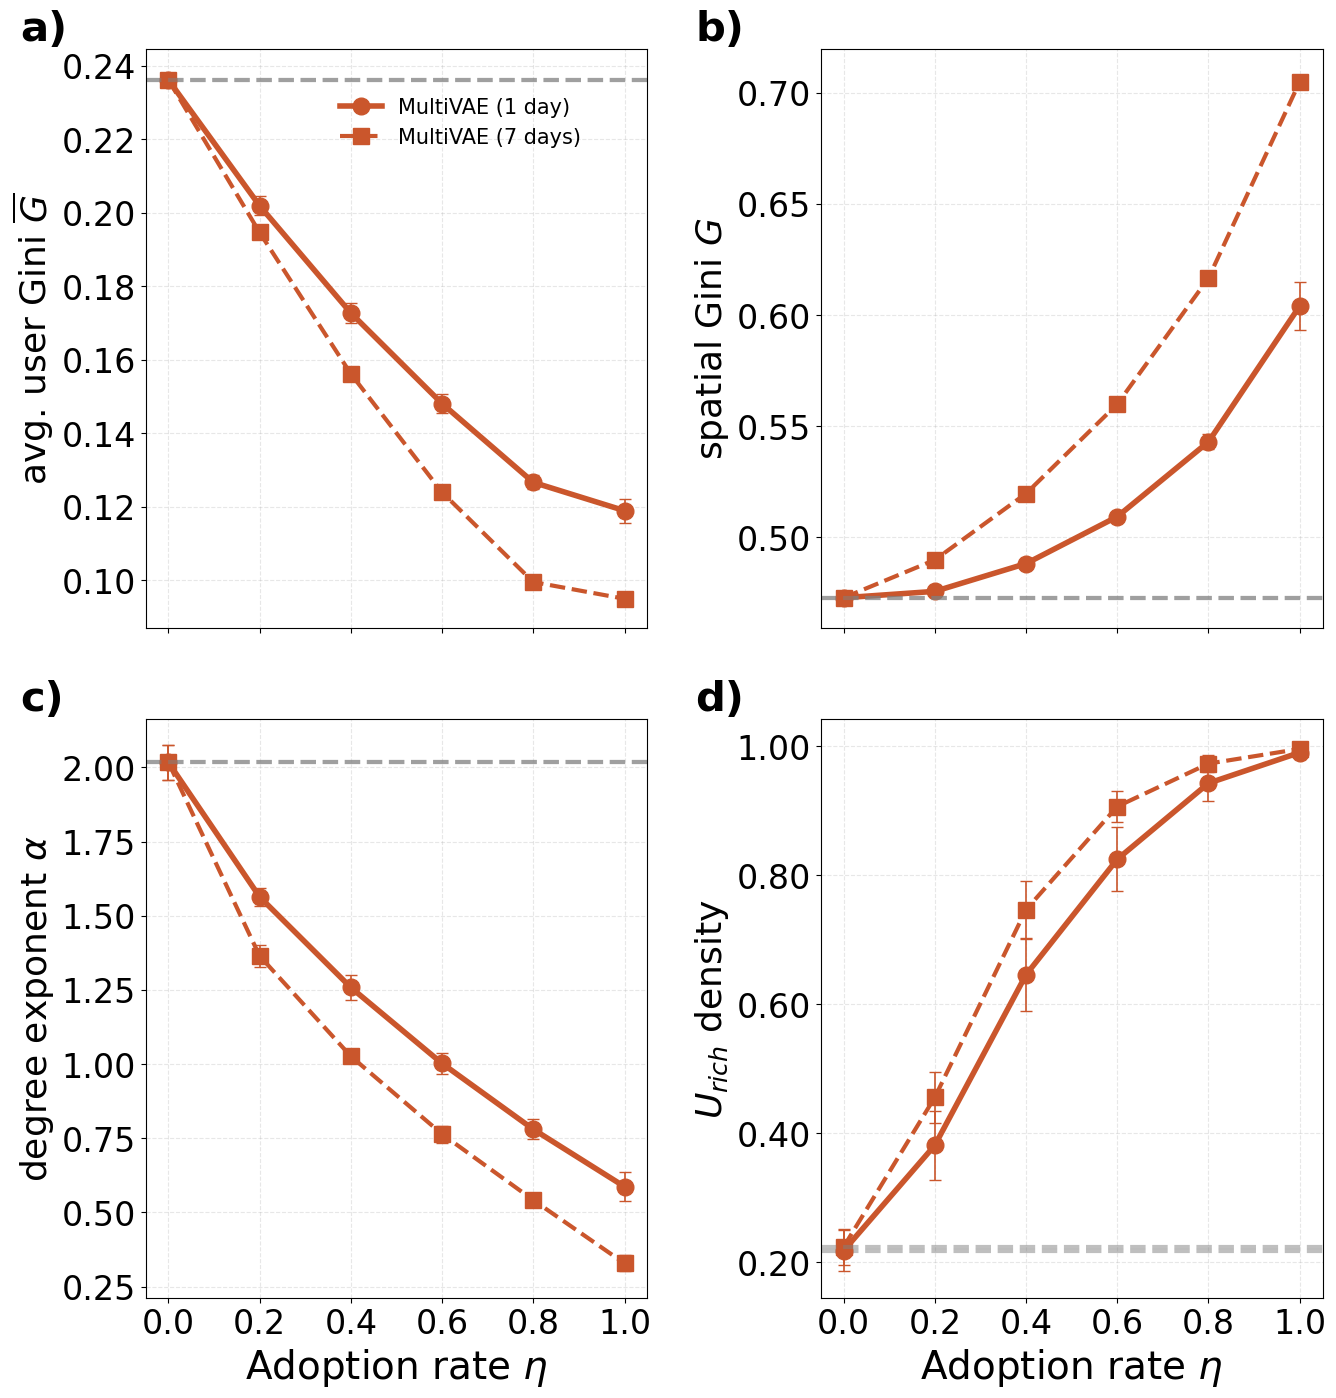

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- User parameters ---
city = "nyc"
# k_days_list = [1, 7, 1000]
k_days_list = [1, 7]

# --- How to display each retraining interval ---
retrain_labels = {
    1:    "1 day",
    7:    "7 days",
    1000: "no retraining",
}
retrain_linestyles = {
    1:    "-",
    7:    "--",
    1000: ":",
}
retrain_markers = {
    1:    "o",   # circle for daily retraining
    7:    "s",   # square for weekly retraining
    1000: "^",   # triangle for no retraining
}
retrain_lw = {
    1:    4.0,  # thick line  
    7:    3.0,  # medium line
    1000: 2.0,  # thin line
}

# --- Discover (or set) the algorithms to plot ---
# You can scan your CSVs to auto-detect, or just hard-code:
# algorithms = sorted(["MultiVAE", "LightGCN"])
algorithms = sorted(["MultiVAE"])

to_remove = ["CPop", "CatRec", "PGN"]
for rem in to_remove:
    if rem in algorithms:
        algorithms.remove(rem)

# --- Color palette per algorithm ---
color_dict = {
    "UserKNN": "#1f77b4",
    "ItemKNN": "#284675",
}
# any new algs get assigned from the nature palette
nature_palette = ["#ca562c", "#8c564b", "#c5b0d5", "#e3b505"]
for i, alg in enumerate([a for a in algorithms if a not in color_dict]):
    color_dict[alg] = nature_palette[i % len(nature_palette)]

# --- Markers & line-styles per algorithm (fallbacks) ---
# you already have some defined; we'll only override retraining markers
markers = {alg: retrain_markers[1] for alg in algorithms}
markers.update({
    "MultiVAE": retrain_markers[7],    # just an example fallback
    "LightGCN": retrain_markers[1000]
})
line_styles = {alg: "-" for alg in algorithms}

# --- Define which subplot each property goes to ---
property_positions = {
    "gamma": (1, 0),
    "rich_club_density": (1, 1),
    "gini_trajectories": (0, 0),
    "gini_visits": (0, 1),
}
property2name = {
    "gamma": r"degree exponent $\alpha$",
    "rich_club_density": r"$U_{rich}$ density",
    "gini_trajectories": r"avg. user Gini $\overline{G}$",
    "gini_visits": r"spatial Gini $G$",
}

# --- X-axis ticks for adoption rate η ---
ps = np.linspace(0, 1, 6)  # [0.0, 0.2, …, 1.0]

# --- Set up the 2×2 figure once ---
fig = plt.figure(figsize=(14, 14), dpi=100)
ax1 = fig.add_subplot(221, aspect='equal')
ax2 = fig.add_subplot(222, aspect='equal')
ax3 = fig.add_subplot(223, aspect='equal', sharex=ax1)
ax4 = fig.add_subplot(224, aspect='equal', sharex=ax2)
axes = np.array([[ax1, ax2],
                 [ax3, ax4]])
# only show x‐labels on bottom row
ax1.tick_params(axis='x', labelbottom=False)
ax2.tick_params(axis='x', labelbottom=False)

# --- Loop over retraining intervals & properties ---
for k_days in k_days_list:
    k_label = retrain_labels[k_days]
    ls      = retrain_linestyles[k_days]
    mk      = retrain_markers[k_days]
    lw      = retrain_lw[k_days]
    prop_dir = f'properties_{city}__k_{k_days}'

    for fname in os.listdir(prop_dir):
        if not fname.endswith('.csv'):
            continue
        prop = fname[:-4]
        if prop not in property_positions:
            continue

        # read & aggregate
        df = pd.read_csv(
            os.path.join(prop_dir, fname),
            sep=",",
            names=['seed','alg','p','value'],
            header=None,
            skipinitialspace=True
        )
        grouped = df.groupby(['alg','p'])['value'].agg(['mean','std']).reset_index()

        row, col = property_positions[prop]
        ax = axes[row, col]

        plotting_order = [alg for alg in algorithms
                          if alg not in ["CatRec","CPop","UserKNN","ItemKNN"]] \
                         + ["UserKNN","ItemKNN"]

        # plot each algorithm
        for alg in plotting_order:
            sub = grouped[grouped['alg'] == alg].sort_values('p')
            if sub.empty:
                continue
            label = f"{alg} ({k_label})"
            ax.plot(
                sub['p'], sub['mean'],
                color     = color_dict[alg],
                linestyle = ls,
                marker    = mk,
                linewidth = lw,
                markersize=12,
                label     = label
            )
            ax.errorbar(
                sub['p'], sub['mean'], yerr=sub['std'],
                fmt='none',
                capsize=4,
                ecolor=color_dict[alg],
                elinewidth=1.2
            )

        # formatting
        ax.set_ylabel(property2name[prop], fontsize=26)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
        ax.set_xticks(ps)
        ax.set_xticklabels([f"{p:.1f}" for p in ps], fontsize=24)
        ax.tick_params(axis='both', which='major', labelsize=24)
        ax.grid(alpha=0.3, linestyle='--')
        ax.set_aspect('auto')
        if row == 1:
            ax.set_xlabel(r'Adoption rate $\eta$', fontsize=28)

        # horizontal baseline at p=0
        if (grouped['p'] == 0).any():
            p0 = grouped.loc[grouped['p'] == 0, 'mean'].iat[0]
            ax.axhline(
                y=p0, color='gray', linestyle='--',
                alpha=0.5, linewidth=3
            )

# --- Replace the master legend with one on ax1 ---
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles, labels,
    loc='upper left',
    bbox_to_anchor=(0.35, 0.95),
    fontsize=15,
    frameon=False,
    borderaxespad=0.5
)

# --- Subplot tags (a), (b), (c), (d) ---
for ax, tag in zip([ax1, ax2, ax3, ax4], ['a)', 'b)', 'c)', 'd)']):
    ax.set_title(tag, fontsize=30, loc='left',
                 fontweight='bold', x=-0.25)

plt.tight_layout(pad=3)
# you can adjust bottom if needed, but we no longer need the big bottom margin
plt.subplots_adjust(bottom=0.05)
plt.show()


--- 
# Plot results with sliding window
#### Change ```k_days``` parameter to visualize at either 1-day or 7-days windows

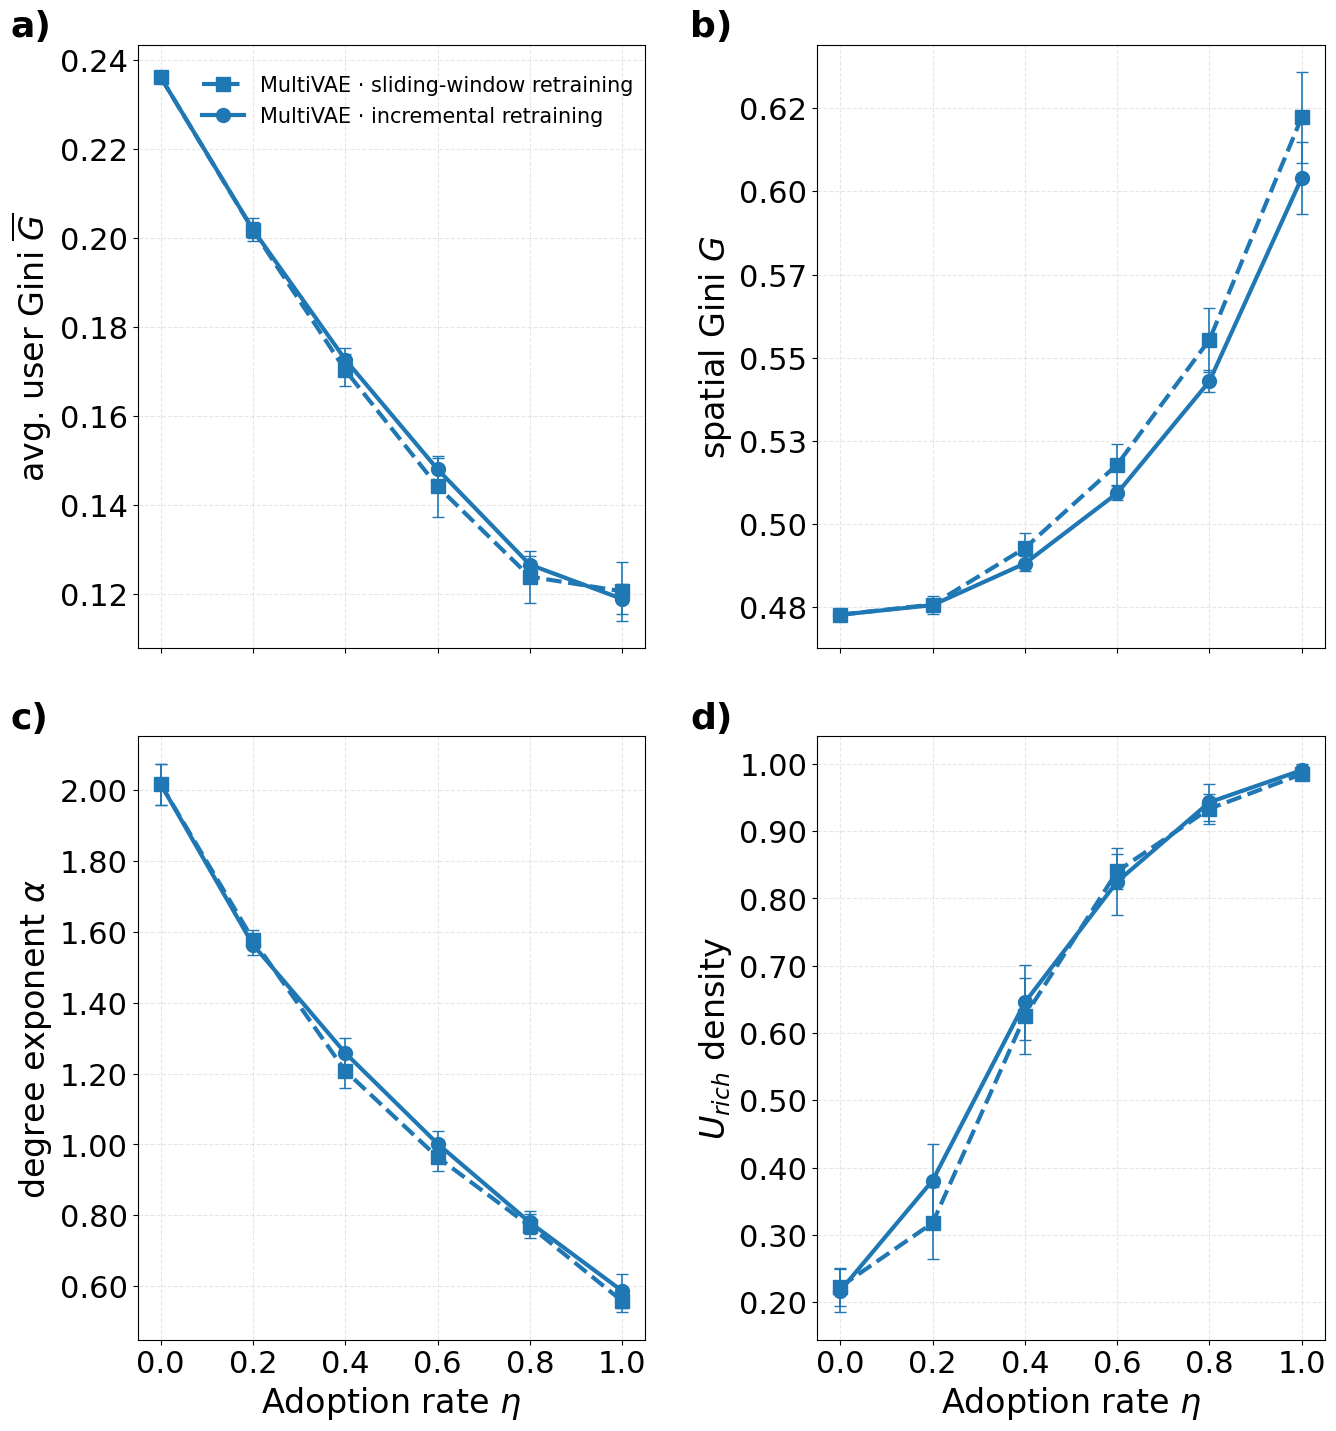

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ---------------------------------------------------------------------------
#  FIXED PARAMETERS
# ---------------------------------------------------------------------------
city   = "nyc"
k_days = 1  # CAMBIARE QUESTO PER CAMBIARE FREQUENZA DI RETRAINING

# plot both data folders
data_folders = [
    (f"SLIDING_properties_{city}__k_{k_days}", "sliding-window retraining"),
    (f"properties_{city}__k_{k_days}",         "incremental retraining"),
]

# ---------------------------------------------------------------------------
#  VISUAL STYLES
# ---------------------------------------------------------------------------
algorithms = ["MultiVAE"]        # extend as needed

color_dict = {
    "MultiVAE": "#1f77b4",
}
marker_dict = {
    "sliding-window retraining":  "s",
    "incremental retraining":     "o",
}
linestyle_dict = {
    "sliding-window retraining":  "--",
    "incremental retraining":     "-",
}
linewidth_dict = {
    "sliding-window retraining":  3.0,
    "incremental retraining":     3.0,
}

property_positions = {
    "gamma": (1, 0),
    "rich_club_density": (1, 1),
    "gini_trajectories": (0, 0),
    "gini_visits": (0, 1),
}
property2name = {
    "gamma": r"degree exponent $\alpha$",
    "rich_club_density": r"$U_{rich}$ density",
    "gini_trajectories": r"avg. user Gini $\overline{G}$",
    "gini_visits": r"spatial Gini $G$",
}

ps = np.linspace(0, 1, 6)  # x-axis ticks

# ---------------------------------------------------------------------------
#  FIGURE
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(14, 14), dpi=100)
ax1 = fig.add_subplot(221, aspect="equal")
ax2 = fig.add_subplot(222, aspect="equal")
ax3 = fig.add_subplot(223, aspect="equal", sharex=ax1)
ax4 = fig.add_subplot(224, aspect="equal", sharex=ax2)
axes = np.array([[ax1, ax2], [ax3, ax4]])

ax1.tick_params(axis="x", labelbottom=False)
ax2.tick_params(axis="x", labelbottom=False)

# ---------------------------------------------------------------------------
#  MAIN LOOP
# ---------------------------------------------------------------------------
for prop_dir, retrain_label in data_folders:
    if not os.path.isdir(prop_dir):
        print(f"Warning: directory '{prop_dir}' not found, skipping.")
        continue

    ls = linestyle_dict[retrain_label]
    mk = marker_dict[retrain_label]
    lw = linewidth_dict[retrain_label]

    for fname in os.listdir(prop_dir):
        if not fname.endswith(".csv"):
            continue
        prop = fname[:-4]
        if prop not in property_positions:
            continue

        df = pd.read_csv(
            os.path.join(prop_dir, fname),
            sep=",",
            names=["seed", "alg", "p", "value"],
            header=None,
            skipinitialspace=True,
        )
        grouped = df.groupby(["alg", "p"])["value"].agg(["mean", "std"]).reset_index()
        
        row, col = property_positions[prop]
        ax = axes[row, col]

        # plot per algorithm
        for alg in algorithms:
            sub = grouped[grouped["alg"] == alg].sort_values("p")
            if sub.empty:
                print(f"sub is empty for {alg}")
                continue
            label = f"{alg} · {retrain_label}"
            ax.plot(
                sub["p"], sub["mean"],
                color=color_dict[alg],
                linestyle=ls,
                marker=mk,
                linewidth=lw,
                markersize=10,
                label=label,
            )
            ax.errorbar(
                sub["p"], sub["mean"],
                yerr=sub["std"],
                fmt="none",
                capsize=4,
                ecolor=color_dict[alg],
                elinewidth=1.2,
            )

        # axis formatting
        ax.set_ylabel(property2name[prop], fontsize=24)
        ax.set_xticks(ps)
        ax.set_xticklabels([f"{p:.1f}" for p in ps], fontsize=22)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
        ax.tick_params(axis="both", labelsize=22)
        ax.grid(alpha=0.3, linestyle="--")
        ax.set_aspect("auto")
        if row == 1:
            ax.set_xlabel(r"Adoption rate $\eta$", fontsize=24)

# ---------------------------------------------------------------------------
#  LEGEND in top-left subplot
# ---------------------------------------------------------------------------
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles, labels,
    loc="upper left",
    bbox_to_anchor=(0.09, 0.98),
    fontsize=15,
    frameon=False,
)

for ax, tag in zip([ax1, ax2, ax3, ax4], ["a)", "b)", "c)", "d)"]):
    ax.set_title(tag, fontsize=26, loc="left", fontweight="bold", x=-0.25)

plt.tight_layout(pad=3)
plt.subplots_adjust(bottom=0.02)
plt.show()
